<a href="https://colab.research.google.com/github/scapps/multiD-fluids-heat/blob/claude%2Finit-chbe3300-jupyter-repo-011CV4eDaH58RgW3YrSVY7e2/01_lid_driven_cavity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lid-Driven Cavity Flow (2-D)

## ChBE 3300: Multidimensional Fluids and Heat Transport

### Problem Description
Simulate fluid flow in a 2-D square cavity with a moving top lid.

This is a classic benchmark problem in computational fluid dynamics.

### Governing Equations
2-D Navier-Stokes equations in vorticity-stream function formulation:

$$\nabla^2 \psi = -\omega$$

$$\frac{\partial \omega}{\partial t} + u\frac{\partial \omega}{\partial x} + v\frac{\partial \omega}{\partial y} = \nu \nabla^2 \omega$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
%matplotlib inline

## 1. Problem Setup

/tmp/ipython-input-1987635385.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


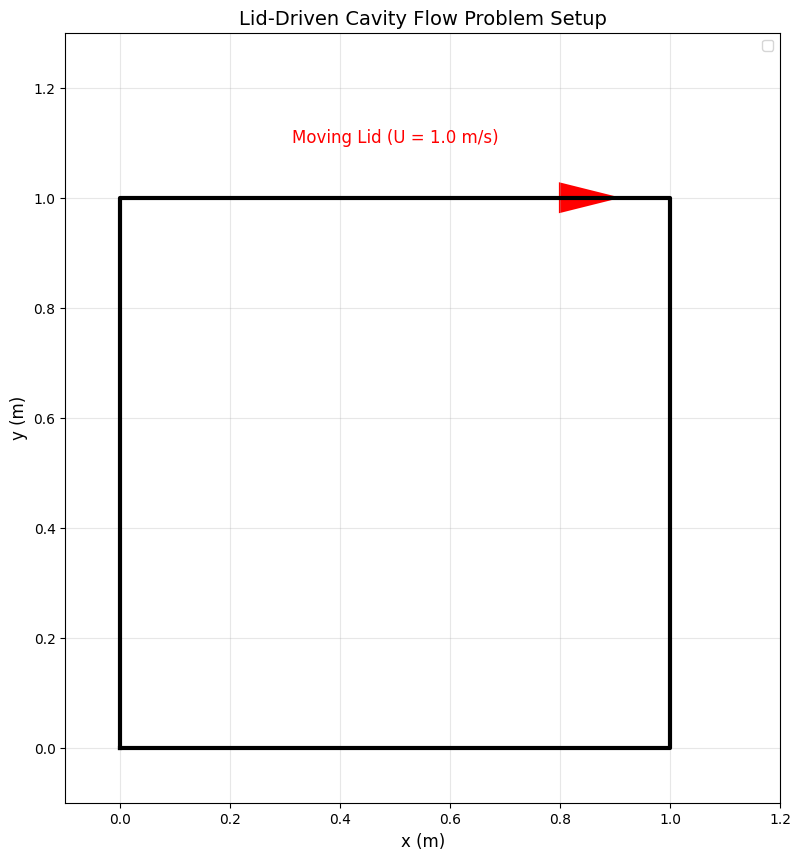

In [11]:
# Create expected flow pattern visualization
fig, ax = plt.subplots(figsize=(10, 10))

# Plot cavity boundary
ax.plot([0, L, L, 0, 0], [0, 0, L, L, 0], 'k-', linewidth=3)

# Arrow indicating lid motion
ax.arrow(0.2, L, 0.6, 0, head_width=0.05, head_length=0.1,
         fc='red', ec='red', linewidth=2)
ax.text(0.5, L+0.1, 'Moving Lid (U = 1.0 m/s)',
        ha='center', fontsize=12, color='red')

ax.set_xlabel('x (m)', fontsize=12)
ax.set_ylabel('y (m)', fontsize=12)
ax.set_title('Lid-Driven Cavity Flow Problem Setup', fontsize=14)
ax.set_aspect('equal')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(-0.1, 1.2)
ax.set_ylim(-0.1, 1.3)

plt.show()

In [12]:
# Physical parameters
L = 1.0           # Cavity size (m)
U_lid = 1.0       # Lid velocity (m/s)
nu = 0.01         # Kinematic viscosity (m²/s)
Re = U_lid * L / nu  # Reynolds number

# Grid parameters
nx = 41
ny = 41
dx = L / (nx - 1)
dy = L / (ny - 1)

# Time parameters
dt = 0.001
nt = 500

print(f"Reynolds number: {Re:.1f}")
print(f"Grid: {nx} x {ny}")
print(f"Time step: {dt} s")
print(f"Total simulation steps: {nt}")

Reynolds number: 100.0
Grid: 41 x 41
Time step: 0.001 s
Total simulation steps: 500


## Task 1: The SIMPLE Algorithm

The **SIMPLE (Semi-Implicit Method for Pressure-Linked Equations)** algorithm is a widely used iterative numerical procedure to solve the Navier-Stokes equations for incompressible fluid flow. It addresses the challenge of coupling pressure and velocity fields, as there is no explicit equation for pressure.

Here's a simplified breakdown of its steps:

### 0.  Guess Pressure Field ($p^*$)
Start by guessing an initial pressure field or using the pressure from the previous iteration.

### 1. Discretized Momentum Equations (Prediction Step)

The momentum equations are first solved using an estimated or 'guessed' pressure field, $p^*$. This yields an intermediate (or 'starred') velocity field $(u^*, v^*)$ that does not necessarily satisfy continuity.

For the x-momentum equation:
$$ \frac{u^* - u^n}{\Delta t} = -\left( u^n \frac{\partial u^n}{\partial x} + v^n \frac{\partial u^n}{\partial y} \right) - \frac{1}{\rho} \frac{\partial p^*}{\partial x} + \nu \left( \frac{\partial^2 u^n}{\partial x^2} + \frac{\partial^2 u^n}{\partial y^2} \right) $$

Similarly, for the y-momentum equation:
$$ \frac{v^* - v^n}{\Delta t} = -\left( u^n \frac{\partial v^n}{\partial x} + v^n \frac{\partial v^n}{\partial y} \right) - \frac{1}{\rho} \frac{\partial p^*}{\partial y} + \nu \left( \frac{\partial^2 v^n}{\partial x^2} + \frac{\partial^2 v^n}{\partial y^2} \right) $$

Where $u^n, v^n$ are velocities from the previous time step, $u^*, v^*$ are intermediate velocities, $p^*$ is the guessed pressure, $\Delta t$ is the time step, $\rho$ is density, and $\nu$ is kinematic viscosity.

These can be rewritten in a more compact form:
$$ u^* = u^n + \Delta t \left[ H_u(u^n, v^n) - \frac{1}{\rho} \frac{\partial p^*}{\partial x} \right] \quad (1) $$
$$ v^* = v^n + \Delta t \left[ H_v(u^n, v^n) - \frac{1}{\rho} \frac{\partial p^*}{\partial y} \right] \quad (2) $$
Where $H_u$ and $H_v$ represent the convective and viscous terms for the respective momentum equations.

### 2. Velocity and Pressure Correction

The intermediate velocities $(u^*, v^*)$ and guessed pressure $p^*$ are then corrected to yield the new, divergence-free velocities $(u^{n+1}, v^{n+1})$ and the corrected pressure $p^{n+1}$. We introduce pressure correction $p'$ such that:

$$ p^{n+1} = p^* + p' \quad (3) $$

And the corrected velocities are related to the intermediate velocities and the pressure correction:

$$ u^{n+1} = u^* - \frac{\Delta t}{\rho} \frac{\partial p'}{\partial x} \quad (4) $$
$$ v^{n+1} = v^* - \frac{\Delta t}{\rho} \frac{\partial p'}{\partial y} \quad (5) $$

### 3. Continuity Equation (Correction Step)

For incompressible flow, the continuity equation must be satisfied:

$$ \frac{\partial u^{n+1}}{\partial x} + \frac{\partial v^{n+1}}{\partial y} = 0 \quad (6) $$

Substitute equations (4) and (5) into (6):

$$ \frac{\partial}{\partial x} \left( u^* - \frac{\Delta t}{\rho} \frac{\partial p'}{\partial x} \right) + \frac{\partial}{\partial y} \left( v^* - \frac{\Delta t}{\rho} \frac{\partial p'}{\partial y} \right) = 0 $$

Rearranging this, we obtain the **Poisson equation for pressure correction**:

$$ \frac{\partial^2 p'}{\partial x^2} + \frac{\partial^2 p'}{\partial y^2} = \frac{\rho}{\Delta t} \left( \frac{\partial u^*}{\partial x} + \frac{\partial v^*}{\partial y} \right) \quad (7) $$

### 4. Solution Procedure

1.  Solve equations (1) and (2) for $u^*$ and $v^*$ using the current pressure $p^*$ (or $p^n$).
2.  Solve the Poisson equation (7) for the pressure correction $p'$.
3.  Update the pressure using equation (3): $p^{n+1} = p^* + p'$.
4.  Correct the velocities using equations (4) and (5) to obtain $u^{n+1}$ and $v^{n+1}$.
5.  Repeat these steps iteratively within each time step until convergence criteria are met (i.e., $p'$ is very small, and the velocities satisfy continuity).

This iterative process ensures that the velocity field is divergence-free at each time step while simultaneously determining the correct pressure field.

## 0. Initialize Fields

In [13]:
# Create grid
x = np.linspace(0, L, nx)
y = np.linspace(0, L, ny)
X, Y = np.meshgrid(x, y)

# Initialize fields
u = np.zeros((ny, nx))  # x-velocity
v = np.zeros((ny, nx))  # y-velocity
p = np.zeros((ny, nx))  # pressure

# Apply boundary condition (moving lid)
u[-1, :] = U_lid

print("Fields initialized")

Fields initialized


## 1. Implement Momentum Equations (Finite Differences)

In [5]:
rho = 1.0 # Assuming density rho = 1 for simplicity

def calculate_momentum_equations(u, v, p, nu, dx, dy, dt, nx, ny, U_lid):
    u_n = u.copy()
    v_n = v.copy()

    # Helper functions for finite differences (central difference for now)
    # du/dx at (i,j)
    dudx = (u_n[1:-1, 2:] - u_n[1:-1, :-2]) / (2 * dx)
    dudy = (u_n[2:, 1:-1] - u_n[:-2, 1:-1]) / (2 * dy)
    dvdx = (v_n[1:-1, 2:] - v_n[1:-1, :-2]) / (2 * dx)
    dvdy = (v_n[2:, 1:-1] - v_n[:-2, 1:-1]) / (2 * dy)

    # d2u/dx2 and d2u/dy2
    d2udx2 = (u_n[1:-1, 2:] - 2 * u_n[1:-1, 1:-1] + u_n[1:-1, :-2]) / (dx**2)
    d2udy2 = (u_n[2:, 1:-1] - 2 * u_n[1:-1, 1:-1] + u_n[:-2, 1:-1]) / (dy**2)

    # d2v/dx2 and d2v/dy2
    d2vdx2 = (v_n[1:-1, 2:] - 2 * v_n[1:-1, 1:-1] + v_n[1:-1, :-2]) / (dx**2)
    d2vdy2 = (v_n[2:, 1:-1] - 2 * v_n[1:-1, 1:-1] + v_n[:-2, 1:-1]) / (dy**2)

    # Pressure gradients
    dpdx = (p[1:-1, 2:] - p[1:-1, :-2]) / (2 * dx)
    dpdy = (p[2:, 1:-1] - p[:-2, 1:-1]) / (2 * dy)

    # Update u velocity (momentum equation in x-direction)
    # u_new = u_old + dt * (convective_terms + pressure_term + viscous_terms)
    u[1:-1, 1:-1] = u_n[1:-1, 1:-1] - dt * (u_n[1:-1, 1:-1] * dudx + v_n[1:-1, 1:-1] * dudy) - \
                    dt / rho * dpdx + \
                    nu * dt * (d2udx2 + d2udy2)

    # Update v velocity (momentum equation in y-direction)
    # v_new = v_old + dt * (convective_terms + pressure_term + viscous_terms)
    v[1:-1, 1:-1] = v_n[1:-1, 1:-1] - dt * (u_n[1:-1, 1:-1] * dvdx + v_n[1:-1, 1:-1] * dvdy) - \
                    dt / rho * dpdy + \
                    nu * dt * (d2vdx2 + d2vdy2)

    # Apply boundary conditions for u and v
    # u boundary conditions
    u[0, :] = 0.0  # Bottom wall
    u[-1, :] = U_lid # Top wall (lid)
    u[:, 0] = 0.0  # Left wall
    u[:, -1] = 0.0 # Right wall

    # v boundary conditions
    v[0, :] = 0.0  # Bottom wall
    v[-1, :] = 0.0 # Top wall
    v[:, 0] = 0.0  # Left wall
    v[:, -1] = 0.0 # Right wall

    return u, v

print("Momentum equation solver function defined.")


Momentum equation solver function defined.


## 2. & 3. Implement Pressure Correction Equation



In [6]:
def solve_pressure_correction(u_star, v_star, p, dx, dy, dt, rho, nx, ny, max_iter=100, tol=1e-5):
    b = np.zeros((ny, nx)) # Source term for Poisson equation
    pn = np.zeros((ny, nx)) # Pressure correction (p_prime)
    p_prime = np.zeros((ny, nx))

    # Calculate the source term 'b' (divergence of intermediate velocities)
    b[1:-1, 1:-1] = rho * ( (u_star[1:-1, 2:] - u_star[1:-1, :-2]) / (2 * dx) + \
                            (v_star[2:, 1:-1] - v_star[:-2, 1:-1]) / (2 * dy) ) / dt

    # Solve Poisson equation for pressure correction using iterative method (Jacobi-like)
    for it in range(max_iter):
        pn = p_prime.copy()
        p_prime[1:-1, 1:-1] = ( (pn[1:-1, 2:] + pn[1:-1, :-2]) * dy**2 + \
                                (pn[2:, 1:-1] + pn[:-2, 1:-1]) * dx**2 - \
                                b[1:-1, 1:-1] * dx**2 * dy**2 ) / (2 * (dx**2 + dy**2))

        # Boundary conditions for pressure correction (dp/dn = 0 at walls)
        # For lid-driven cavity, often assume dp/dn=0 at all walls for correction
        p_prime[:, 0] = p_prime[:, 1]    # Left wall
        p_prime[:, -1] = p_prime[:, -2]  # Right wall
        p_prime[0, :] = p_prime[1, :]    # Bottom wall
        p_prime[-1, :] = p_prime[-2, :]  # Top wall

        if np.max(np.abs(p_prime - pn)) < tol:
            break

    # Correct pressure and velocities
    # p_new = p_old + p_prime
    p[1:-1, 1:-1] = p[1:-1, 1:-1] + p_prime[1:-1, 1:-1]

    # Correct velocities (u_new = u_star - dt/rho * dp_prime/dx)
    u_corrected = u_star.copy()
    v_corrected = v_star.copy()

    u_corrected[1:-1, 1:-1] = u_star[1:-1, 1:-1] - dt / rho * (p_prime[1:-1, 2:] - p_prime[1:-1, :-2]) / (2 * dx)
    v_corrected[1:-1, 1:-1] = v_star[1:-1, 1:-1] - dt / rho * (p_prime[2:, 1:-1] - p_prime[:-2, 1:-1]) / (2 * dy)

    # Apply boundary conditions for corrected velocities (same as before)
    u_corrected[0, :] = 0.0
    u_corrected[-1, :] = U_lid # Note: U_lid should be passed or global
    u_corrected[:, 0] = 0.0
    u_corrected[:, -1] = 0.0

    v_corrected[0, :] = 0.0
    v_corrected[-1, :] = 0.0
    v_corrected[:, 0] = 0.0
    v_corrected[:, -1] = 0.0

    return u_corrected, v_corrected, p

print("Pressure correction solver function defined.")


Pressure correction solver function defined.


## 4. Main Simulation Loop (SIMPLE Algorithm)

In [7]:
# Main SIMPLE algorithm loop
print("Starting simulation...")

for t_step in range(nt):
    # 1. Store previous time step values for intermediate calculations
    u_prev = u.copy()
    v_prev = v.copy()
    p_prev = p.copy()

    # 2. Solve Momentum Equations to get u_star and v_star (intermediate velocities)
    #    The calculate_momentum_equations function already updates u and v in place
    #    but we need to pass a copy to avoid modifying them before pressure correction.
    #    For SIMPLE, u_star and v_star are typically calculated using the pressure from the previous iteration/timestep.
    #    Here, we'll calculate them using 'p_prev' as the 'guessed' pressure.

    # We need to simulate the prediction step where u and v are calculated using p_prev
    # The function 'calculate_momentum_equations' returns updated u and v
    # Let's rename the output to be explicit about u_star and v_star
    u_star, v_star = calculate_momentum_equations(u_prev, v_prev, p_prev, nu, dx, dy, dt, nx, ny, U_lid)

    # 3. Solve Pressure Correction Equation and correct velocities and pressure
    u, v, p = solve_pressure_correction(u_star, v_star, p, dx, dy, dt, rho, nx, ny, max_iter=100, tol=1e-5)

    # Optional: Check for overall convergence (e.g., if max velocity change is below a threshold)
    # Not implemented for simplicity in this basic loop.

    if t_step % 100 == 0 or t_step == nt - 1:
        print(f"Time step {t_step}/{nt} completed.")

print("Simulation finished.")


Starting simulation...
Time step 0/500 completed.
Time step 100/500 completed.
Time step 200/500 completed.
Time step 300/500 completed.
Time step 400/500 completed.
Time step 499/500 completed.
Simulation finished.


## Visualization of Results

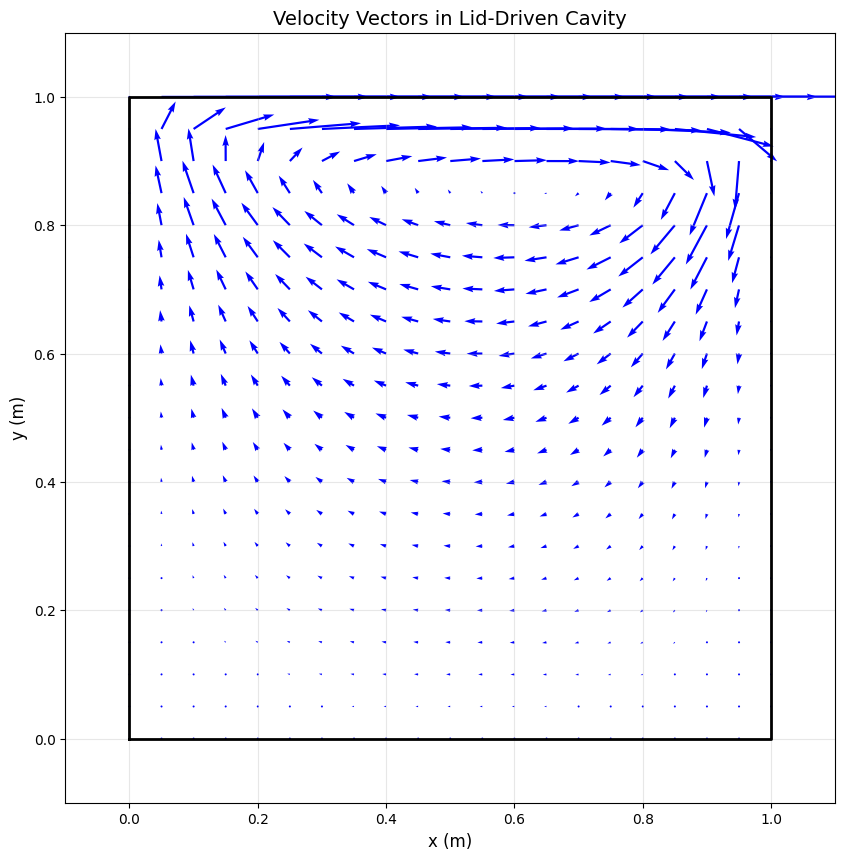

In [8]:
fig, ax = plt.subplots(figsize=(10, 10))

# Quiver plot for velocity vectors
# We'll plot every Nth arrow to avoid overcrowding
skip = 2
ax.quiver(X[::skip, ::skip], Y[::skip, ::skip],
          u[::skip, ::skip], v[::skip, ::skip], color='blue')

# Plot cavity boundary
ax.plot([0, L, L, 0, 0], [0, 0, L, L, 0], 'k-', linewidth=2)

ax.set_xlabel('x (m)', fontsize=12)
ax.set_ylabel('y (m)', fontsize=12)
ax.set_title('Velocity Vectors in Lid-Driven Cavity', fontsize=14)
ax.set_aspect('equal')
ax.set_xlim(-0.1, 1.1)
ax.set_ylim(-0.1, 1.1)
ax.grid(True, alpha=0.3)

plt.show()


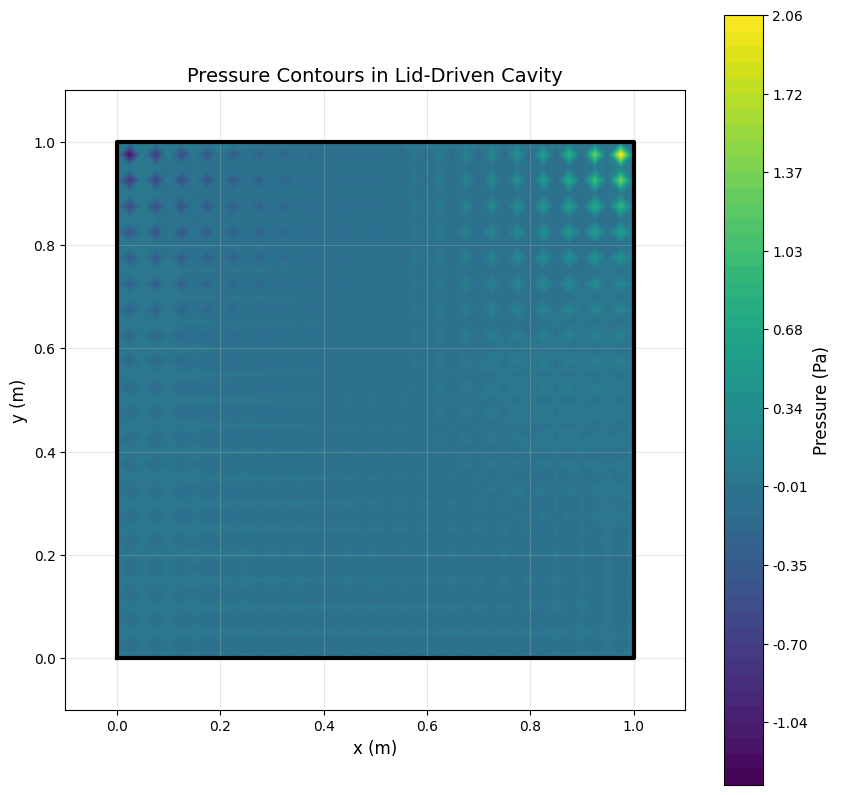

In [9]:
fig, ax = plt.subplots(figsize=(10, 10))

# Pressure contours
levels = np.linspace(p.min(), p.max(), 50) # Adjust number of levels for desired detail
contour = ax.contourf(X, Y, p, levels=levels, cmap=cm.viridis)
cbar = fig.colorbar(contour, ax=ax, format="%.02f")
cbar.set_label('Pressure (Pa)', fontsize=12)

# Plot cavity boundary
ax.plot([0, L, L, 0, 0], [0, 0, L, L, 0], 'k-', linewidth=3)

ax.set_xlabel('x (m)', fontsize=12)
ax.set_ylabel('y (m)', fontsize=12)
ax.set_title('Pressure Contours in Lid-Driven Cavity', fontsize=14)
ax.set_aspect('equal')
ax.set_xlim(-0.1, 1.1)
ax.set_ylim(-0.1, 1.1)
ax.grid(True, alpha=0.3)

plt.show()


## References

1. Ghia, U., Ghia, K. N., & Shin, C. T. (1982). High-Re solutions for incompressible flow using the Navier-Stokes equations and a multigrid method. *Journal of Computational Physics*, 48(3), 387-411.

2. Barba, L. A., & Forsyth, G. F. (2018). CFD Python: 12 steps to Navier-Stokes.